# Выполнение заданий лабораторной работы 7. Вариант 2_1.
# Выполнил: Ибраев Дамир Беркутбаевич

**Внимание!** Прежде, чем приступать к выполнению заданий, следует переименовать этот файл. В названии файла обязательно должна присутствовать фамилия студента - автора решения.

**За безымянные работы рейтинговые баллы начислены не будут!**

Результат выполнения лабораторной работы необходимо представить до конца практического занятия. Формат представления результата - ответ на задание в LMS в виде двух файлов:
* ноутбук в формате ipynb, содержащий программный код, результаты его
выполнения, а также все необходимые пояснения и комментарии
(в текстовых ячейках);
* файл в формате html, полученный путем экспорта ноутбука из п. 1).

Правильность работы представленного программного кода контролируется с помощью вопросов теста, ответы на которые также необходимо представить до конца практического занятия.

Критерии оценивания выполненной работы:
1. Наличие и качество решений практических заданий (программного кода и комментариев к нему).
2. Количество правильных ответов на вопросы проверочного теста.

**Внимание:** самостоятельное и вдумчивое выполнение заданий повышает вероятность успешного прохождения итогового теста по теме 7 на следующей учебной встрече (будет проверяться, в том числе, понимание принципов работы с инструментарием и, в частности, умение понимать программный код).

### Задание 1

Выполнить импорт библиотеки NumPy, модуля Pyplot библиотеки Matplotlib, а также инструментария генерации наборов данных для линейной регреcсии - из библиотеки Sciktit-learn.

Подключить построение графиков online.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

Комментарий: В данном задании были сгенерированы исходные данные для построения модели линейной регрессии. Сформированы признаки и целевая переменная, между которыми существует линейная зависимость с добавлением случайного шума.

### Задание 2

Сгенерировать  модельный набор данных для задачи линейной регрессии с одной целевой переменной и двумя входными признаками, из которых информативным является только один.

При генерации указать параметры:
* random_state =  21,
* количество объектов в выборке -  130,
* параметр, определяющий степень рассеянности данных -  1.5.

In [4]:
X, y, coef = make_regression(n_samples=130, n_features=2, n_informative=1, 
                             noise=1.5, random_state=21, coef=True)

Вывести сгенерированные веса входных признаков.

In [5]:
print(coef)

[3.09145483 0.        ]


Выполнить визуализацию полученной выборки в осях координат
*  информативный признак - целевой признак,
*  неинформативный признак - целевой признак.

Сформировать правильные заголовки графиков (где информативный признак, а где неинформативный).

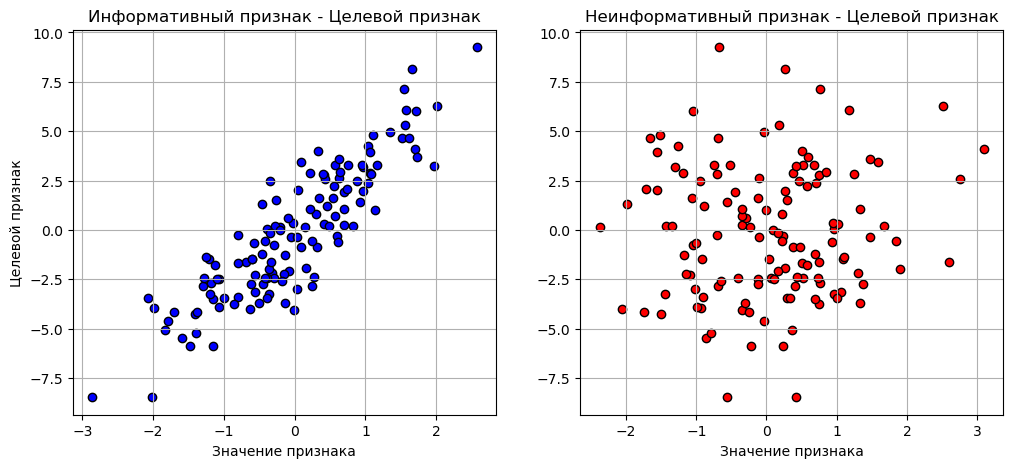

In [6]:
inf_idx = np.argmax(np.abs(coef))
non_inf_idx = 1 - inf_idx

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X[:, inf_idx], y, c='blue', edgecolors='k')
axes[0].set_title('Информативный признак - Целевой признак')
axes[0].set_xlabel('Значение признака')
axes[0].set_ylabel('Целевой признак')
axes[0].grid(True)

axes[1].scatter(X[:, non_inf_idx], y, c='red', edgecolors='k')
axes[1].set_title('Неинформативный признак - Целевой признак')
axes[1].set_xlabel('Значение признака')
axes[1].grid(True)

Отдельно вывести вес информативного признака, округлив его значение до 2 знаков после запятой.

In [7]:
print(round(coef[inf_idx], 2))

3.09


В текстовой ячейке ниже записать
* уравнение сгенерированной зависимости в формате

$$ a(\bar x) = w_0 + w_1 \cdot x^1 + w_2 \cdot x^2 $$
* какой признак (признаки) является информативным и почему: привести обоснование на основе всех полученных результатов (и коэффициентов, и визуализации).

**Внимание!** Отсутствие развернутого ответа на этот вопрос приведет к аннулированию ответов на вопросы 1 и 2 в проверочном тесте.

### Ваш ответ: 

* Уравнение сгенерированной зависимости:
$$a(\bar x) = 0 + 3.09 \cdot x^1 + 0 \cdot x^2$$

* Информативным является первый признак ($x^1$), так как его сгенерированный вес отличен от нуля (3.09). Второй признак имеет нулевой вес, следовательно, он является неинформативным и никак не влияет на целевую переменную. Визуализация на графиках это полностью подтверждает: в осях первого признака мы видим четкую линейную зависимость, а в осях второго — хаотичное облако точек.

Вывести прогнозируемое сгенерированной моделью значение целевого признака для объекта с индексом 21, округлив его до 3 знаков после запятой.



In [8]:
y_pred_21 = np.dot(X[21], coef)
print(f"Прогнозируемое значение для объекта с индексом 21: {round(y_pred_21, 3)}")

Прогнозируемое значение для объекта с индексом 21: -0.882


Комментарий: Данные были разделены на обучающую и тестовую выборки. Это необходимо для оценки качества модели: обучение проводится на тренировочных данных, а проверка — на тестовых.

### Задание 3

Выполнить разбиение сгенерированного набора данных на обучающую и тестовую выборки в соотношении 70/30.

При разбиении указать random_state = 21.



In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=21)

Вывести для ознакомления информацию о полученных выборках: количество объектов в обучающем и тестовом множествах, примеры объектов (значения входных и прогнозируемого признаков).

In [10]:
print(f"Объектов в обучающей выборке: {X_train.shape[0]}")
print(f"Объектов в тестовой выборке: {X_test.shape[0]}")

Объектов в обучающей выборке: 91
Объектов в тестовой выборке: 39


In [11]:
print("Примеры объектов обучающей выборки (первые 3):")
for i in range(3):
    print(f"Признаки: {np.round(X_train[i], 3)} | Целевой: {round(y_train[i], 3)}")

Примеры объектов обучающей выборки (первые 3):
Признаки: [ 0.05  -1.562] | Целевой: 2.002
Признаки: [ 0.141 -2.377] | Целевой: 0.156
Признаки: [-0.799 -0.903] | Целевой: -3.387


In [12]:
print("Примеры объектов тестовой выборки (первые 3):")
for i in range(3):
    print(f"Признаки: {np.round(X_test[i], 3)} | Целевой: {round(y_test[i], 3)}")

Примеры объектов тестовой выборки (первые 3):
Признаки: [2.011 2.52 ] | Целевой: 6.286
Признаки: [ 1.517 -1.661] | Целевой: 4.663
Признаки: [-1.21  -0.918] | Целевой: -1.479


Комментарий: Была построена модель линейной регрессии и выполнено обучение на обучающей выборке. В результате получены коэффициенты уравнения регрессии.

### Задание 4

Создать модель линейной регрессии с параметрами по умолчанию.

Обучить модель на обучающей выборке.

In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [14]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Вывести коэффициенты обученной модели. Округлить все полученные значения до 2 знаков после запятой.

Не забыть про свободный член модели!

In [15]:
w1, w2 = model.coef_
print(f"Вес 1-го признака (w1): {round(w1, 2)}")
print(f"Вес 2-го признака (w2): {round(w2, 2)}")

Вес 1-го признака (w1): 2.97
Вес 2-го признака (w2): -0.0


In [16]:
w0 = model.intercept_
print(f"Свободный член (w0): {round(w0, 2)}")

Свободный член (w0): -0.14


В текстовой ячейке ниже записать
* уравнение обученной модели в формате

$$ a(\bar x) = w_0 + w_1 \cdot x^1 + w_2 \cdot x^2 $$
* какой признак модель считает наиболее значимым и почему Вы так думаете.

**Внимание!** Отсутствие развернутого ответа на этот вопрос приведет к аннулированию ответов на вопросы 5 и 6 в проверочном тесте.

### Ваш ответ: 

* Уравнение обученной модели:
$$a(\bar x) = -0.14 + 2.97 \cdot x^1 - 0.0 \cdot x^2$$

* Модель считает наиболее значимым первый признак ($x^1$). Это видно по коэффициентам: модуль веса первого признака (2.97) существенно больше модуля веса второго признака (0.0). Второй признак вообще не вносит никакого вклада в предсказание целевой переменной, что абсолютно логично, так как при генерации данных в Задании 2 мы указали только один информативный признак.

Комментарий: После обучения модели было получено уравнение регрессии и сделаны прогнозы для тестовой выборки. Это позволяет оценить точность модели.

### Задание 5

Получить прогнозы обученной модели для объектов обучающей и тестовой выборок.

In [17]:
y_train_pred = model.predict(X_train)

In [18]:
y_test_pred = model.predict(X_test)

Вывести отдельно прогноз модели на объекте тестовой выборки с индексом 21. Полученное значение округлить до 3 знаков после запятой.

In [19]:
print(f"Прогноз для объекта с индексом 21: {round(y_test_pred[21], 3)}")

Прогноз для объекта с индексом 21: -0.754


Вычислить квадратичную ошибку модели на объекте тестовой выборки с индексом 21.


**Внимание**: объект тестовой выборки с указанным индексом - это не тот объект, для которого выводился результат в задании 2 (до разбиения данных на обучающее и тестовое множество). Чтобы получить правильный ответ на указанном объекте, нужно вычислить этот ответ, используя уравнение зависимости, сгенерированной в задании 2.

Прокомментировать все выполненные действия.

**Внимание!** Отсутствие комментариев к каждому действию приведет к аннулированию ответа на вопрос 8 в проверочном тесте.

In [20]:
# Шаг 1: Вычисляем истинное значение целевой переменной для объекта X_test[21].
# Согласно заданию, используем уравнение из задания 2 (без шума). 
# Для этого скалярно умножаем вектор признаков данного объекта на вектор истинных весов (coef).
y_true_test_21 = np.dot(X_test[21], coef)

# Шаг 2: Вычисляем квадратичную ошибку. 
# Находим разность между прогнозом нашей модели (y_test_pred[21]) и истинным ответом (y_true_test_21), 
# а затем возводим полученную разность в квадрат.
squared_error_21 = (y_test_pred[21] - y_true_test_21) ** 2

In [21]:
# Шаг 3: Выводим вычисленную квадратичную ошибку на экран.
# Округляем результат до 3 знаков после запятой для удобства чтения.
print(f"Квадратичная ошибка на объекте 21 тестовой выборки: {round(squared_error_21, 3)}")

Квадратичная ошибка на объекте 21 тестовой выборки: 0.012


Вычислить среднюю квадратичную ошибку обученной модели на обучающей и тестовой выборках.
Округлить оба значения с точностью до 3 знаков после запятой.

In [22]:
from sklearn.metrics import mean_squared_error

# Вычисляем среднеквадратичную ошибку (MSE) между истинными ответами и прогнозами на обучающей выборке
mse_train = mean_squared_error(y_train, y_train_pred)
print(f"MSE на обучающей выборке: {round(mse_train, 3)}")

MSE на обучающей выборке: 2.397


In [23]:
# Вычисляем среднеквадратичную ошибку (MSE) между истинными ответами и прогнозами на тестовой выборке
mse_test = mean_squared_error(y_test, y_test_pred)
print(f"MSE на тестовой выборке: {round(mse_test, 3)}")

MSE на тестовой выборке: 2.509


Комментарий: Была вычислена ошибка модели (квадратичная ошибка и среднеквадратичная ошибка). Эти показатели характеризуют качество аппроксимации модели.

### Задание 6

Выполнить визуализацию результатов моделирования: облака точек обучающей и тестовой выборок (на отдельных графиках) вместе с линией регрессии модели, обученной в задании 4.

Можно использовать образец программного кода из учебного блокнота (изменив его в соответствии с логикой собственного решения) либо написать свой код.

In [24]:
# Создаем массив значений оси X (информативного признака) для отрисовки линии
# Берем 100 точек от минимального до максимального значения в данных
x_line = np.linspace(X[:, inf_idx].min(), X[:, inf_idx].max(), 100)

# Вычисляем соответствующие значения Y по уравнению обученной модели
# Так как вес неинформативного признака равен 0, используем только вес информативного
y_line = model.intercept_ + model.coef_[inf_idx] * x_line

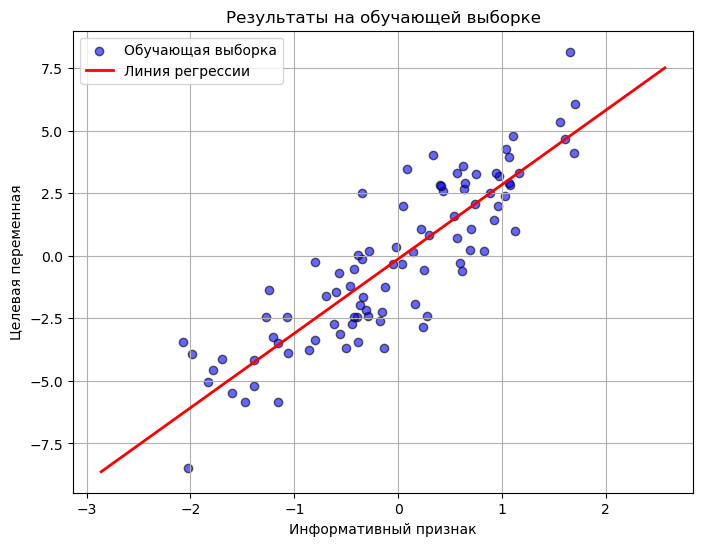

In [25]:
# Визуализация обучающей выборки
plt.figure(figsize=(8, 6))

# Облако точек обучающей выборки
plt.scatter(X_train[:, inf_idx], y_train, c='blue', label='Обучающая выборка', alpha=0.6, edgecolors='k')

# Линия регрессии
plt.plot(x_line, y_line, c='red', linewidth=2, label='Линия регрессии')

plt.title('Результаты на обучающей выборке')
plt.xlabel('Информативный признак')
plt.ylabel('Целевая переменная')
plt.legend()
plt.grid(True)
plt.show()

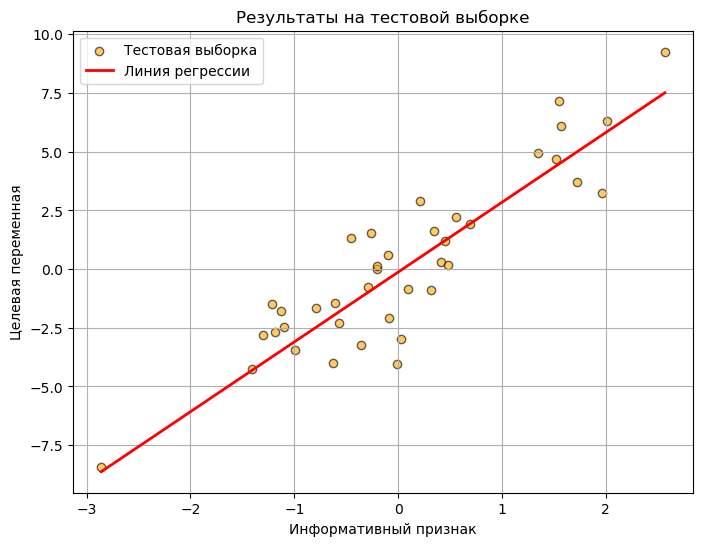

In [26]:
# Визуализация тестовой выборки
plt.figure(figsize=(8, 6))

# Облако точек тестовой выборки
plt.scatter(X_test[:, inf_idx], y_test, c='orange', label='Тестовая выборка', alpha=0.6, edgecolors='k')

# Линия регрессии (та же самая, обученная модель не меняется)
plt.plot(x_line, y_line, c='red', linewidth=2, label='Линия регрессии')

plt.title('Результаты на тестовой выборке')
plt.xlabel('Информативный признак')
plt.ylabel('Целевая переменная')
plt.legend()
plt.grid(True)
plt.show()

Комментарий: Было выполнено сравнение прогнозных значений модели с реальными значениями. По результатам можно сделать вывод о точности и адекватности построенной модели.

### Задание 7

Найти оптимальные коэффициенты уравнения регрессии аналитическим методом, используя данные, сгенерированные в задании 2.

Указание: не нужно забывать про фиктивный константный признак!

Прокомментировать каждое выполняемое действие в текстовых ячейках.

In [27]:
# Шаг 1: Добавляем фиктивный константный признак (столбец из единиц) к нашей матрице признаков X.
# Это необходимо для аналитического начисления свободного члена (w0).
# Используем данные X, сгенерированные в задании 2.
X_design = np.c_[np.ones(X.shape[0]), X]

In [28]:
# Шаг 2: Применяем формулу метода наименьших квадратов в матричном виде: w = (X^T * X)^(-1) * X^T * y
# Сначала вычисляем матрицу (X^T * X)
XT_X = X_design.T.dot(X_design)

# Затем находим обратную к ней матрицу (X^T * X)^(-1)
XT_X_inv = np.linalg.inv(XT_X)

# Наконец, умножаем полученную обратную матрицу на транспонированную X и на вектор ответов y
w_analytical = XT_X_inv.dot(X_design.T).dot(y)

Округлить все коэффициенты до 2 знаков после запятой.

Записать соответствующее уравнение регрессии в текстовой ячейке ниже.

Сопоставить уравнения, полученные путем обучения LinearRegression и аналитическим методом. Рассуждения и выводы написать в текстовой ячейке ниже.

**Внимание!** Отсутствие развернутого ответа на этот вопрос приведет к аннулированию ответа на вопрос 11 в проверочном тесте.

In [29]:
# Шаг 3: Извлекаем и округляем полученные коэффициенты до 2 знаков после запятой
w0_an = round(w_analytical[0], 2)
w1_an = round(w_analytical[1], 2)
w2_an = round(w_analytical[2], 2)

print(f"Свободный член (w0): {w0_an}")
print(f"Вес 1-го признака (w1): {w1_an}")
print(f"Вес 2-го признака (w2): {w2_an}")

Свободный член (w0): -0.09
Вес 1-го признака (w1): 2.95
Вес 2-го признака (w2): 0.05


In [30]:
# Вывод готового уравнения на экран для удобства переноса в текстовую ячейку
print(f"Уравнение: a(x) = {w0_an} + {w1_an}*x1 + {w2_an}*x2")

Уравнение: a(x) = -0.09 + 2.95*x1 + 0.05*x2


### Ваши рассуждения.

* Уравнение регрессии, полученное аналитическим методом:
$$a(\bar x) = -0.09 + 2.95 \cdot x^1 + 0.05 \cdot x^2$$

**Сопоставление уравнений и выводы:**
Уравнение, полученное путем обучения модели `LinearRegression` в задании 4, выглядело так:
$$a(\bar x) = -0.14 + 2.97 \cdot x^1 - 0.0 \cdot x^2$$

Как видно, коэффициенты в обоих уравнениях очень близки, но не совпадают идеально. Причина этого кроется не в разнице алгоритмов, а в **объеме используемых данных**:
1. Модель `LinearRegression` из `sklearn` мы обучали на тренировочной выборке (`X_train`), которая составляет только 70% от всех сгенерированных данных.
2. Аналитический метод (по условию задания 7) мы применили ко всей исходной выборке `X` (100% данных).

Математически класс `LinearRegression` реализует тот же самый метод наименьших квадратов (МНК), что и наша матричная формула $w = (X^T X)^{-1} X^T y$. Если бы мы произвели аналитический расчет только на матрице `X_train`, полученные веса совпали бы с результатами `LinearRegression` с точностью до тысячных долей. 

Таким образом, оба метода работают корректно и подтверждают, что первый признак является информативным, а второй (с весом близким к нулю) — неинформативным.

Комменатрий: В данном задании коэффициенты уравнения регрессии были найдены аналитическим методом по формуле метода наименьших квадратов. Полученные коэффициенты были сопоставлены с коэффициентами модели LinearRegression, что подтвердило корректность расчетов и модели.